Figure S7: Phenotype filtering by FDR prior to finemapping. A Q-values from permutation mode of Tensorqtl for eGene phenotypes and pcGene phenotypes each run together, vs each run individually. Boxes give the number of eGene and pcGene phenotypes in each quadrant, with significance cutoffs of q<0.05, a 5% FDR. B For each eGene or pcGene with a significant finemapped SuSiE credible set, the distribution of tensorQTL permutation q-values from combined mapping on pcGenes and eGenes together. Dotted lines represent q-values for 5%, 1% and 0.1% FDR cutoffs. All eGenes and pcGenes with a credible set would pass 5% FDR. All eGenes and all but one pcGene with a credible set would pass 1% FDR. C Discovery of credible-set-groups at various combined q-value thresholds in a two-step QTL mapping process. At each q-value cutoff, we subset to only credible sets mapped on pcGenes and eGenes with q < cutoff. Then, pcQTL and eQTL credible sets are again grouped by colocalizations and the groups are classified according to whether the contain only pcQTL credible sets, only eQTL credible sets, both eQTL and pcQTL credible sets, or no longer contain any credible sets.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm 
import plotly.graph_objs as go


tqdm.pandas()

# get outputs from a config file
import yaml
config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import * 

%config InlineBackend.figure_formats = ['png']

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

# Define colors for eQTL vs pcQTL
qtl_colors = {'eQTL': '#6FA287', 'pcQTL': '#620059'}

In [3]:
# load nominal p values
nominal = load_across_tissues(config, load_combined_cis)
nominal['cluster_id'] = nominal['phenotype_id'].str.split('_pc').str[0].str.split('_e').str[0]
nominal['short_phenotype_id'] = nominal['cluster_id'].str.split('_').str[-1] + '_' + np.where(nominal['phenotype_id'].str.contains('_pc'), 'pc', 'e') + '_' + nominal['phenotype_id'].str.split('_pc').str[-1].str.split('_e_').str[-1]
nominal['qtl_type'] = np.where(nominal['phenotype_id'].str.contains('_pc'), 'pcQTL', 'eQTL')
nominal['is_sig'] = nominal['qval'] < 0.05

# load credible set groups
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['pcQTL'] = qtl_signal_groups['num_pc_coloc'] > 0
qtl_signal_groups['eQTL'] = qtl_signal_groups['num_e_coloc'] > 0
qtl_signal_groups['exclusive_label'] = np.where((qtl_signal_groups['num_e_coloc'] > 0), np.where((qtl_signal_groups['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')
qtl_signal_groups['cs_id'] = qtl_signal_groups['signal_id'].str.split('-')
groups_explode = qtl_signal_groups.explode('cs_id')
groups_explode['phenotype_id'] = groups_explode['cs_id'].str.split('_cs').str[0]
groups_explode['cluster_id'] = groups_explode['phenotype_id'].str.split('_pc').str[0].str.split('_e').str[0]
groups_explode['short_phenotype_id'] = groups_explode['cluster_id'].str.split('_').str[-1] + '_' + np.where(groups_explode['phenotype_id'].str.contains('_pc'), 'pc', 'e') + '_' + groups_explode['phenotype_id'].str.split('_pc').str[-1].str.split('_e_').str[-1]
groups_explode['qtl_type'] = np.where(groups_explode['phenotype_id'].str.contains('_pc'), 'pcQTL', 'eQTL')


# add in the per phenotype p-value
groups_explode = pd.merge(groups_explode, nominal[['short_phenotype_id', 'tissue_id', 'pval_nominal', 'qval', 'is_sig']], on=['short_phenotype_id', 'tissue_id'], how='left')

In [4]:
# how many pass 5% fDR (topmed threshold)
print("{:.2f}% (all but {}) of phenotypes pass 5% fDR (topmed threshold)".format((groups_explode['qval']<0.05).mean()*100, (groups_explode['qval']>0.05).sum()))
print("{:.2f}% (all but {}) of phenotypes pass 1% fDR (eQTL catelogue threshold)".format((groups_explode['qval']<0.01).mean()*100, (groups_explode['qval']>0.01).sum()))
print("{:.2f}% (all but {}) of phenotypes pass 0.1% fDR (eQTL catelogue threshold)".format((groups_explode['qval']<0.001).mean()*100, (groups_explode['qval']>0.001).sum()))

100.00% (all but 0) of phenotypes pass 5% fDR (topmed threshold)
100.00% (all but 1) of phenotypes pass 1% fDR (eQTL catelogue threshold)
99.75% (all but 92) of phenotypes pass 0.1% fDR (eQTL catelogue threshold)


In [15]:
eqtl_alone = load_across_tissues(config, load_e_cis)
eqtl_alone['qtl_type'] = 'eQTL'
pcqtl_alone = load_across_tissues(config, load_pc_cis)
pcqtl_alone['qtl_type'] = 'pcQTL'


eqtl_alone['signifigant'] = eqtl_alone['qval'] < 0.05
pcqtl_alone['signifigant'] = pcqtl_alone['qval'] < 0.05
nominal['signifigant'] = nominal['qval'] < 0.05

along_merged = pd.concat([eqtl_alone, pcqtl_alone], keys=['eQTL', 'pcQTL'], names=['source']).reset_index()
merged = pd.merge(along_merged[['phenotype_id', 'tissue_id', 'source', 'signifigant', 'qval']], nominal[['phenotype_id', 'tissue_id', 'signifigant', 'qval']], on=['phenotype_id', 'tissue_id'], how='left', suffixes=('_alone', '_combined'))

merged['signifigant_flag'] = np.where(merged['signifigant_alone'], 
    np.where(merged['signifigant_combined'], 'both', 'alone_only'),
    np.where(merged['signifigant_combined'], 'combined_only', 'none'))

In [14]:
print("{}/{} eqtls significant alone".format(eqtl_alone['signifigant'].sum(), eqtl_alone.shape[0]))
print("{}/{} pcqtl significant alone".format(pcqtl_alone['signifigant'].sum(), pcqtl_alone.shape[0]))
print("{}/{} eqtls significant combined".format(nominal[nominal['qtl_type'] == 'eQTL']['signifigant'].sum(), nominal[nominal['qtl_type'] == 'eQTL'].shape[0]))
print("{}/{} pcqtl significant combined".format(nominal[nominal['qtl_type'] == 'pcQTL']['signifigant'].sum(), nominal[nominal['qtl_type'] == 'pcQTL'].shape[0]))

20923/26435 eqtls significant alone
21381/26435 pcqtl significant alone
21007/26435 eqtls significant combined
21116/26435 pcqtl significant combined


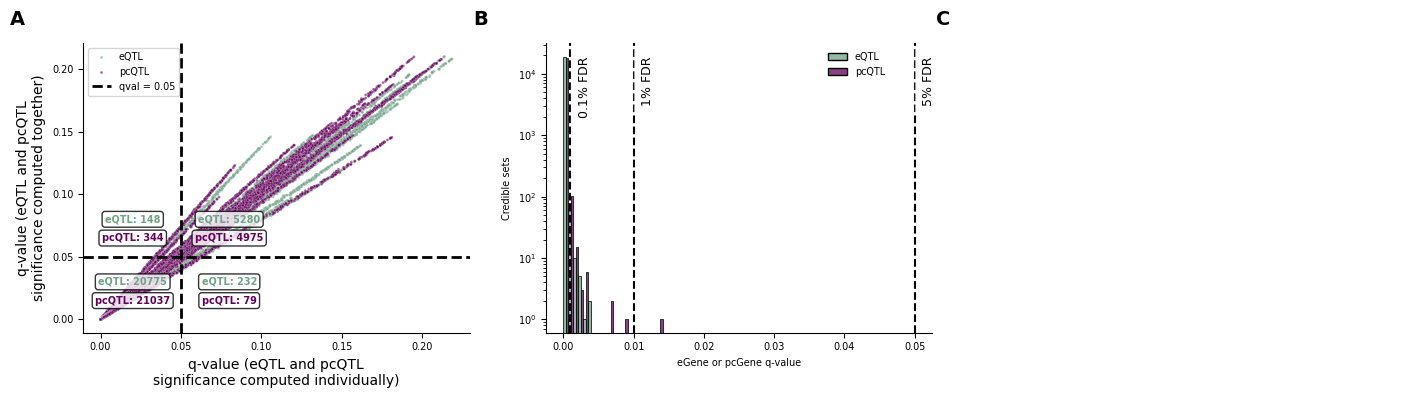

In [43]:
# Make a three-panel figure, now scatterplot is panel a (left), histogram is panel b (center), blank panel c (right)
fig, axs = plt.subplots(1, 3, figsize=(14, 4), gridspec_kw={'width_ratios': [1, 1, 1]})

# --- SCATTERPLOT -- panel a (left) ---
ax = axs[0]
ax.text(-0.15, 1.05, 'A', transform=ax.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')
sns.scatterplot(data=merged, x='qval_alone', y='qval_combined', hue='source', alpha=0.6, s=4, palette=qtl_colors, ax=ax)

# Add significance lines
ax.axhline(y=0.05, color='k', linestyle='--', linewidth=2, label='qval = 0.05')
ax.axvline(x=0.05, color='k', linestyle='--', linewidth=2)

ax.set_xlabel('q-value (eQTL and pcQTL\nsignificance computed individually)', fontsize=10)
ax.set_ylabel('q-value (eQTL and pcQTL\nsignificance computed together)', fontsize=10)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Calculate counts for each quadrant by source
top_left_eqtl = merged[(merged['qval_alone'] <= 0.05) & (merged['qval_combined'] > 0.05) & (merged['source'] == 'eQTL')].shape[0]
top_left_pcqtl = merged[(merged['qval_alone'] <= 0.05) & (merged['qval_combined'] > 0.05) & (merged['source'] == 'pcQTL')].shape[0]
top_right_eqtl = merged[(merged['qval_alone'] > 0.05) & (merged['qval_combined'] > 0.05) & (merged['source'] == 'eQTL')].shape[0]
top_right_pcqtl = merged[(merged['qval_alone'] > 0.05) & (merged['qval_combined'] > 0.05) & (merged['source'] == 'pcQTL')].shape[0]
bottom_left_eqtl = merged[(merged['qval_alone'] <= 0.05) & (merged['qval_combined'] <= 0.05) & (merged['source'] == 'eQTL')].shape[0]
bottom_left_pcqtl = merged[(merged['qval_alone'] <= 0.05) & (merged['qval_combined'] <= 0.05) & (merged['source'] == 'pcQTL')].shape[0]
bottom_right_eqtl = merged[(merged['qval_alone'] > 0.05) & (merged['qval_combined'] <= 0.05) & (merged['source'] == 'eQTL')].shape[0]
bottom_right_pcqtl = merged[(merged['qval_alone'] > 0.05) & (merged['qval_combined'] <= 0.05) & (merged['source'] == 'pcQTL')].shape[0]

left_text_x = 0.02
upper_text_y = 0.08
right_text_x = 0.08
lower_text_y = 0.03
diff_y = 0.015

# Add colored text for each source separately
ax.text(left_text_x, upper_text_y, f'eQTL: {top_left_eqtl}', 
        ha='center', va='center', color=qtl_colors['eQTL'],fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(left_text_x, upper_text_y - diff_y, f'pcQTL: {top_left_pcqtl}',
        ha='center', va='center', color=qtl_colors['pcQTL'], fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(right_text_x, upper_text_y, f'eQTL: {top_right_eqtl}', fontweight='bold',
        ha='center', va='center', color=qtl_colors['eQTL'], 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(right_text_x, upper_text_y - diff_y, f'pcQTL: {top_right_pcqtl}', fontweight='bold',
        ha='center', va='center', color=qtl_colors['pcQTL'], 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(left_text_x, lower_text_y, f'eQTL: {bottom_left_eqtl}',
        ha='center', va='center', color=qtl_colors['eQTL'],fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(left_text_x, lower_text_y - diff_y, f'pcQTL: {bottom_left_pcqtl}',
        ha='center', va='center', color=qtl_colors['pcQTL'], fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(right_text_x, lower_text_y, f'eQTL: {bottom_right_eqtl}',
        ha='center', va='center', color=qtl_colors['eQTL'], fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(right_text_x, lower_text_y - diff_y, f'pcQTL: {bottom_right_pcqtl}',
        ha='center', va='center', color=qtl_colors['pcQTL'],fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
# Add legend
ax.legend()

# --- HISTOGRAM -- panel b (middle) ---
ax2 = axs[1]
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')
hist = sns.histplot(groups_explode, x='qval', bins=20, hue='qtl_type', ax=ax2, palette=qtl_colors, legend=True, multiple='dodge')
sns.move_legend(hist, "upper right", bbox_to_anchor=(.9, 1), title='', frameon=False)

# Draw vertical lines and label them near the tops
y_max = ax2.get_ylim()[1]
vlines = [
    (0.05, '5% FDR'),
    (0.01, '1% FDR'),
    (0.001, '0.1% FDR')
]
for x, lbl in vlines:
    ax2.axvline(x, color='black', linestyle='--')
    ax2.text(
        x+.002,
        y_max * 0.96,
        lbl,
        rotation=90,
        va='top',
        ha='center',
        backgroundcolor=(1, 1, 1, 0.5),
        fontsize=9
    )

ax2.set_yscale('log')
ax2.set_xlabel('eGene or pcGene q-value')
ax2.set_ylabel('Credible sets')
sns.despine(ax=ax2)

# --- BLANK PANEL C (right) ---
ax3 = axs[2]
ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes, fontsize=14, fontweight='bold', 
         ha='right', va='bottom')
ax3.axis('off')

plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s7.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

In [42]:
# Track and plot (signal_id, tissue_id) pairs that are never significant (i.e., "Not sig" at every cutoff)
# Sankey flows HORIZONTALLY: left = all loci, right = stricter q-value cutoffs

group_labels = ['Not sig', 'Both', 'eQTL only', 'pcQTL only']
group_palette = {
    'Not sig': 'grey',
    'Both': '#007C92',
    'eQTL only': '#6FA287',
    'pcQTL only': '#620059',
}
q_cutoffs = [1, 0.05, 0.01, 0.001]

# For each cutoff, map (signal_id, tissue_id) -> group label
groupings = {}
def assign_label(qtls):
    qtls = set(qtls)
    if qtls == {'eQTL'}:
        return 'eQTL only'
    elif qtls == {'pcQTL'}:
        return 'pcQTL only'
    elif qtls == {'eQTL','pcQTL'}:
        return 'Both'
    else:
        return 'Neither'

for cutoff in q_cutoffs:
    qdf = groups_explode[groups_explode['qval'] < cutoff]
    type_table = (qdf.drop_duplicates(['signal_id','tissue_id','qtl_type'])
                    .groupby(['signal_id','tissue_id'])['qtl_type']
                    .unique())
    groupings[cutoff] = type_table.apply(assign_label)

# Build full index of all (signal_id, tissue_id) ever present
all_idx = pd.MultiIndex.from_frame(groups_explode[['signal_id', 'tissue_id']].drop_duplicates())
for g in groupings.values():
    all_idx = all_idx.union(g.index)
sankey_df = pd.DataFrame(index=all_idx)
for cutoff in q_cutoffs:
    sankey_df[str(cutoff)] = groupings[cutoff].reindex(all_idx, fill_value='Neither')

# Map "Neither" to "Not sig" in every column
for col in sankey_df.columns:
    sankey_df[col] = sankey_df[col].replace('Neither', 'Not sig')

# Setup node info/labels for Sankey (horizontal)
node_labels = []
label_map = {}
node_colors = []
# Track for annotation positions (above)
node_indices_by_stage = {}

node_idx = 0
for i, cutoff in enumerate(q_cutoffs):
    stage_indices = []
    for group in group_labels:
        lab = f"{group} (q<{cutoff:.0e})"
        node_labels.append(lab)
        label_map[lab] = node_idx
        node_colors.append(group_palette[group])
        stage_indices.append(node_idx)
        node_idx += 1
    node_indices_by_stage[i] = stage_indices

# Prep links for Sankey (horizontal: source = previous cutoff, target = next cutoff)
sources, targets, values, link_labels = [], [], [], []
for j in range(len(q_cutoffs)-1):
    cur, nxt = str(q_cutoffs[j]), str(q_cutoffs[j+1])
    for gfrom in group_labels:
        for gto in group_labels:
            mask = (sankey_df[cur] == gfrom) & (sankey_df[nxt] == gto)
            count = mask.sum()
            if count > 0:
                src = f"{gfrom} (q<{q_cutoffs[j]:.0e})"
                tgt = f"{gto} (q<{q_cutoffs[j+1]:.0e})"
                sources.append(label_map[src])
                targets.append(label_map[tgt])
                values.append(count)
                link_labels.append(str(count))

# Node counts for display
node_counts = [(sankey_df[str(q)].values == group).sum() for q in q_cutoffs for group in group_labels]

# Node labels: just counts (no group labels)
labels_with_counts = [str(c) for c in node_counts]

# Sankey with node labels as counts only
horizontal_sankey = go.Sankey(
    orientation='h',
    node = dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels_with_counts,
        color=node_colors,
    ),
    link = dict(
        source=sources,
        target=targets,
        value=values,
        # Remove the label param; we'll annotate labels manually instead
        color="rgba(100,100,100,0.2)",
        customdata = link_labels,
        hovertemplate = 'Count: %{customdata}',
    )
)

fig = go.Figure(horizontal_sankey)

# Add q-value label annotations above each stage, from left to right (NOT rotated, keep horizontal)
cutoff_labels = ['All loci', '5%', '1%', '0.1%']
for stage, cutoff_lab in enumerate(cutoff_labels):
    x_frac = stage/(len(q_cutoffs)-1) if len(q_cutoffs)>1 else 0
    fig.add_annotation(
        x=x_frac, y=1.09, xref='paper', yref='paper', text=cutoff_lab, showarrow=False,
        font=dict(size=11, color="black"),
        xanchor='center', yanchor='bottom', textangle=0
    )

fig.add_annotation(
    x=0.5, y=-.1, xref='paper', yref='paper',
    text="q-value cutoff applied to pcGene/eGene phenotypes",
    showarrow=False, font=dict(size=13, color="black"),
    xanchor='center', yanchor='bottom', textangle=0
)

fig.update_layout(
    width=400, height=400,
    font_size=10,
    title_text="",
    margin=dict(l=40, r=40, t=90, b=40)
)
fig.show()